# Capstone Function 6
You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

 Input | Output | Goal |
|-------|--------|------|
| 5D Array (20, 5) | 1D Array (20, ) | Maximise |

## Initial Submission

Bayesian Optimization for 5D cake recipe (flour, sugar, eggs, butter, milk) to maximize combined score.

### Step 1: Import Libraries

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Ready!")

Ready!


### Step 2: Load & Visualize Data

In [7]:
X_init = np.load('../../data/f6/initial_inputs.npy')
y_init = np.load('../../data/f6/initial_outputs.npy')
ingredients = ['Flour', 'Sugar', 'Eggs', 'Butter', 'Milk']
print(f"Loaded 5D cake recipe data: {X_init.shape[0]} samples")
print(f"Best score: {y_init.max():.6f}")

Loaded 5D cake recipe data: 20 samples
Best score: -0.714265


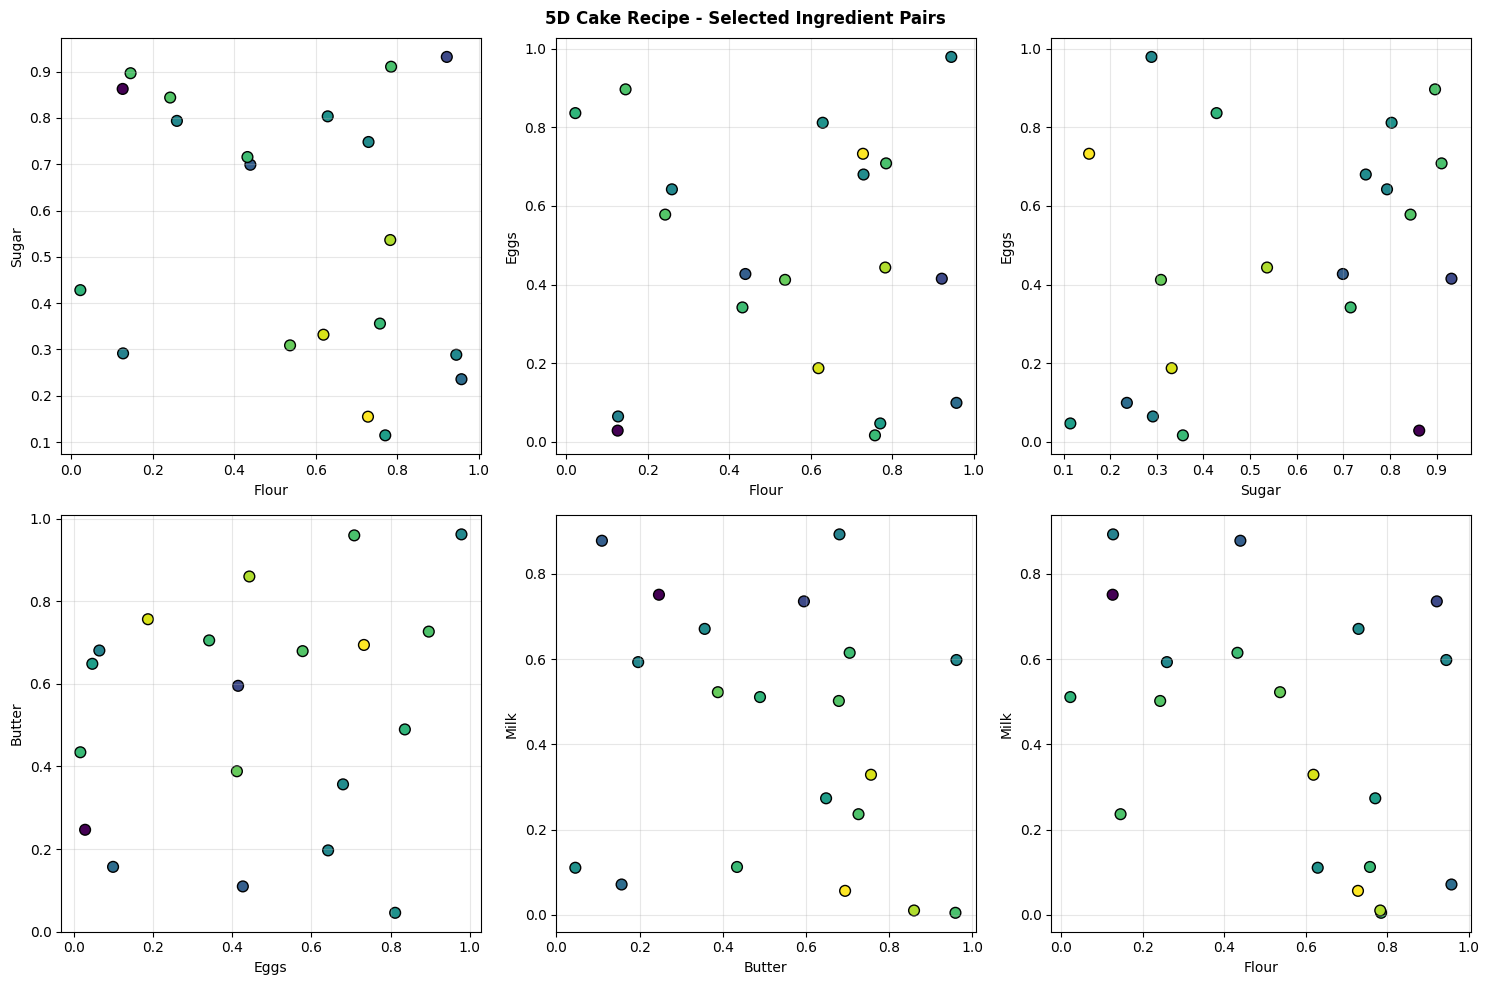

In [8]:
# Visualize selected pairs (5D has 10 pairs - show subset)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (1,2), (2,3), (3,4), (0,4)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='viridis', edgecolors='black', s=60)
    axes[idx].set_xlabel(ingredients[i])
    axes[idx].set_ylabel(ingredients[j])
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('5D Cake Recipe - Selected Ingredient Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters

**5D Cake Recipe:**
- Restarts: 20, Raw: 2048 (higher dimensional space)
- EI with GP Matern 5/2 kernel

In [ ]:
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 20, 2048
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next recipe: {dict(zip(ingredients, next_point))}")

✓ Next recipe: {'Flour': np.float64(0.48172097280865894), 'Sugar': np.float64(0.34948774631193963), 'Eggs': np.float64(0.5780362640197754), 'Butter': np.float64(0.8017174054982571), 'Milk': np.float64(0.15507549757310288)}


### Step 4: Visualize Progress & Lengthscales

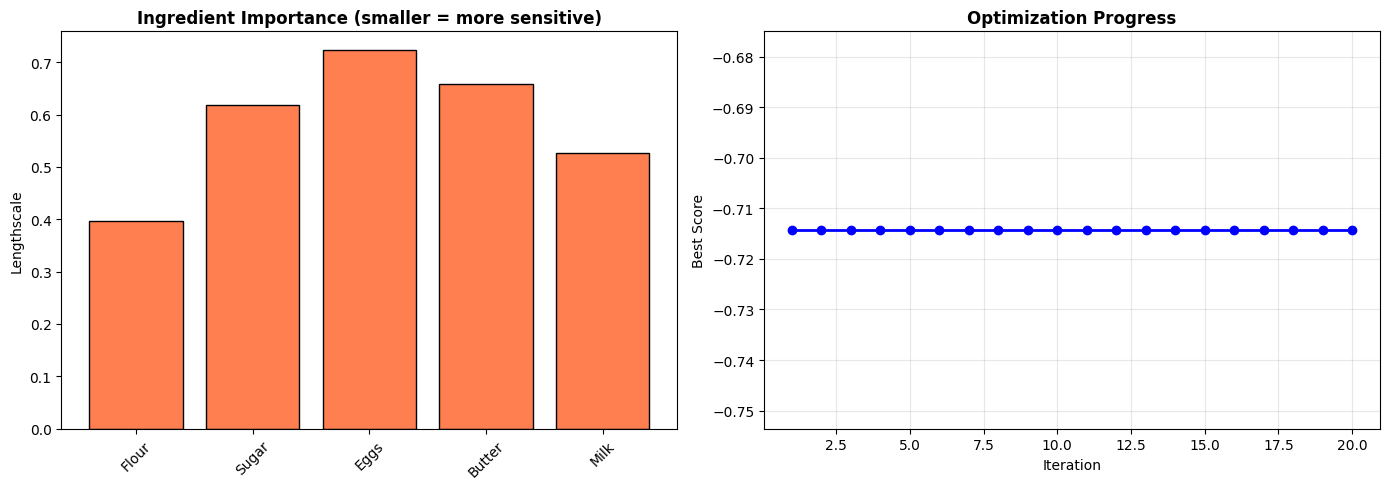

Next: [0.48172097 0.34948775 0.57803626 0.80171741 0.1550755 ]


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Safe lengthscale access (kernel structure may vary)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

ax1.bar(ingredients, ls, color='coral', edgecolor='black')
ax1.set_ylabel('Lengthscale')
ax1.set_title('Ingredient Importance (smaller = more sensitive)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'b-o', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Score')
ax2.set_title('Optimization Progress', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Next: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 0.999999, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 6")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")